# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.


## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [83]:
import sys




## 2. Imports and Reproducibility


In [102]:
import os
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras import layers, models, optimizers
os.environ["TF_USE_LEGACY_KERAS"] = "1"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


TensorFlow version: 2.21.0
TF-MOT version: 0.8.1


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [103]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    !wget -q "{dataset_url}" -O "{zip_path}"
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 4. Load the Data


In [104]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # 1. Load X_train from train/X_train.txt
    # 2. Load y_train from train/y_train.txt
    # 3. Load X_test from test/X_test.txt
    # 4. Load y_test from test/y_test.txt
    # 5. Convert the labels to zero-based class indices by subtracting 1

    # Load feature matrices
    X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt"))
    X_test = np.loadtxt(os.path.join(root_dir, "test", "X_test.txt"))

    # Load labels
    y_train = np.loadtxt(
        os.path.join(root_dir, "train", "y_train.txt"),dtype=int
    )
    y_test = np.loadtxt(
        os.path.join(root_dir, "test", "y_test.txt"),dtype=int
    )

    # step 5
    y_train = y_train - 1
    y_test = y_test - 1

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

num_features = X_train.shape[1]
num_classes = len(class_names)

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)
print("Number of features:", num_features)
print("Number of classes:", num_classes)


Training data shape: (7352, 561)
Test data shape: (2947, 561)
Number of features: 561
Number of classes: 6


## 5. Quick Inspection


In [87]:
class_counts = []

for i in range(num_classes):
    count = 0
    for label in y_train:
        if label == i:
            count += 1
    class_counts.append(count)

# Create the summary table
summary_table = pd.DataFrame({
    "Class Index": list(range(num_classes)),
    "Class Name": class_names,
    "Training Samples": class_counts
})

summary_table


,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [88]:
def build_baseline_model(input_dim, num_classes):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 256)            │       143,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,414 (724.27 KB)

 Trainable params: 185,414 (724.27 KB)

 Non-trainable params: 0 (0.00 B)

### Train the Baseline Model


In [89]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

result = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks
)


Epoch 1/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8075 - loss: 0.4880 - val_accuracy: 0.9245 - val_loss: 0.2016
Epoch 2/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9417 - loss: 0.1500 - val_accuracy: 0.9388 - val_loss: 0.1372
Epoch 3/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9502 - loss: 0.1222 - val_accuracy: 0.9409 - val_loss: 0.1411
Epoch 4/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9701 - loss: 0.0805 - val_accuracy: 0.9381 - val_loss: 0.1393
Epoch 5/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9694 - loss: 0.0833 - val_accuracy: 0.9395 - val_loss: 0.1630
Epoch 6/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9668 - loss: 0.0849 - val_accuracy: 0.9470 - val_loss: 0.1264
Epoch 7/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9721 - loss: 0.0683 - val_accuracy: 0.9429 - val_loss: 0.1301
Epoch 8/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9646 - loss: 0.0885 - val_accuracy: 0.9463 - val_loss:

### Training Curves


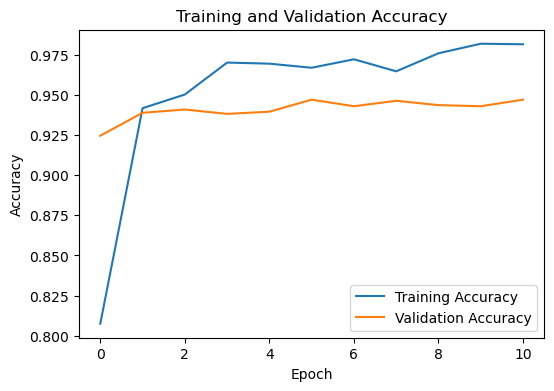

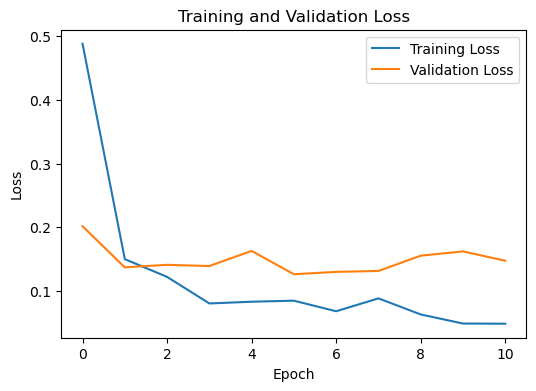

In [90]:
# Accuracy
plt.figure(figsize=(6,4))
plt.plot(result.history["accuracy"], label="Training Accuracy")
plt.plot(result.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

# Loss
plt.figure(figsize=(6,4))
plt.plot(result.history["loss"], label="Training Loss")
plt.plot(result.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

## 7. Evaluate the Baseline Keras Model


93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 742us/step
Test Accuracy: 0.9409569053274517
                    precision    recall  f1-score   support

           WALKING       0.97      0.96      0.96       496
  WALKING_UPSTAIRS       0.95      0.96      0.96       471
WALKING_DOWNSTAIRS       0.94      0.94      0.94       420
           SITTING       0.94      0.87      0.90       491
          STANDING       0.86      0.95      0.90       532
            LAYING       1.00      0.97      0.98       537

          accuracy                           0.94      2947
         macro avg       0.94      0.94      0.94      2947
      weighted avg       0.94      0.94      0.94      2947



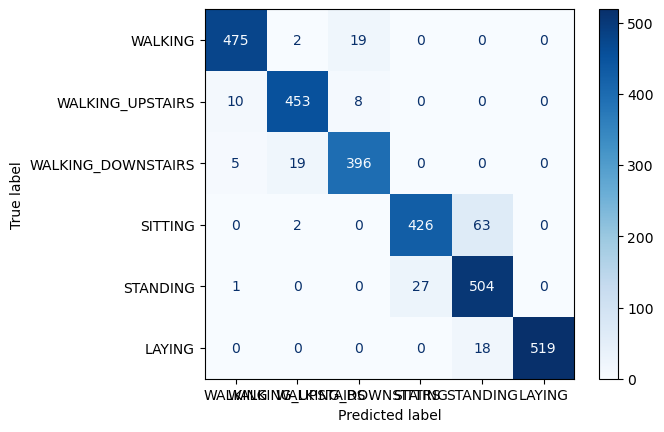

In [91]:
# 1. Obtain predicted probabilities on X_test
# 2. Convert them to class predictions using argmax
# 3. Compute test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix


# Predicted probabilities
y_prob = baseline_model.predict(X_test)

# Convert to predicted classes
y_pred = np.argmax(y_prob, axis=1)

# Test accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_accuracy)

# Classification report
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=class_names)
disp.plot(cmap="Blues")
plt.show()


## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.


In [92]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def representative_dataset_gen():
    for i in range(300):
        sample = X_train[i:i+1].astype(np.float32)
        yield [sample]


def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the input dtype is int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.

        if input_details["dtype"] == np.int8:
            x = (x / input_scale + input_zero_point).astype(np.int8)

        elif input_details["dtype"] == np.uint8:
            x = (x / input_scale + input_zero_point).astype(np.uint8)

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        if output_details["dtype"] == np.int8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        elif output_details["dtype"] == np.uint8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # Apply default optimization and return the converted model.

    converter.optimizations = [
        tf.lite.Optimize.DEFAULT
    ]

    return converter.convert()

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # Apply default optimization
    # Set supported_types to [tf.float16]
    # Return the converted model

    converter = tf.lite.TFLiteConverter.from_keras_model(model)

    converter.optimizations = [
        tf.lite.Optimize.DEFAULT
    ]

    converter.target_spec.supported_types = [
        tf.float16
    ]

    return converter.convert()

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # Apply default optimization
    # Attach representative_dataset_gen
    # Restrict to TFLITE_BUILTINS_INT8
    # Set inference_input_type and inference_output_type to tf.int8
    # Return the converted model

    converter.optimizations = [
        tf.lite.Optimize.DEFAULT
    ]

    converter.representative_dataset = representative_dataset_gen

    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS_INT8
    ]

    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8

    return converter.convert()


## 9. Post-Training Quantization (PTQ)


In [93]:
# Convert the baseline model into:
# - FP32 TFLite
# - dynamic range TFLite
# - float16 TFLite
# - int8 TFLite

# Save each model to disk and record its size in KB.
# Evaluate each TFLite model on the test set.
tflite_results = []

# --- FP32 ---
tflite_fp32 = convert_to_tflite_fp32(baseline_model)
size_fp32 = save_binary_model(tflite_fp32, "model_fp32.tflite")
acc_fp32, _ = evaluate_tflite_model(tflite_fp32, X_test, y_test)
tflite_results.append(("Baseline", "FP32", acc_fp32, size_fp32))
print(f"FP32: acc={acc_fp32:.4f}, size={size_fp32:.2f} KB")

# --- Dynamic range quantization ---
tflite_dr = convert_to_tflite_dynamic_range(baseline_model)
size_dr = save_binary_model(tflite_dr, "model_dynamic_range.tflite")
acc_dr, _ = evaluate_tflite_model(tflite_dr, X_test, y_test)
tflite_results.append(("Baseline", "Dynamic Range", acc_dr, size_dr))
print(f"Dynamic Range: acc={acc_dr:.4f}, size={size_dr:.2f} KB")

# --- Float16 quantization ---
tflite_fp16 = convert_to_tflite_float16(baseline_model)
size_fp16 = save_binary_model(tflite_fp16, "model_float16.tflite")
acc_fp16, _ = evaluate_tflite_model(tflite_fp16, X_test, y_test)
tflite_results.append(("Baseline", "Float16", acc_fp16, size_fp16))
print(f"Float16: acc={acc_fp16:.4f}, size={size_fp16:.2f} KB")

# --- Int8 PTQ ---
tflite_int8 = convert_to_tflite_int8(baseline_model)
size_int8 = save_binary_model(tflite_int8, "model_int8_ptq.tflite")
acc_int8_ptq, y_pred_int8_ptq = evaluate_tflite_model(tflite_int8, X_test, y_test)
tflite_results.append(("Baseline", "Int8 PTQ", acc_int8_ptq, size_int8))
print(f"Int8 PTQ: acc={acc_int8_ptq:.4f}, size={size_int8:.2f} KB")


INFO:tensorflow:Assets written to: /var/folders/3d/q5ysxhdn59d06w5th7xvl18m0000gn/T/tmpxcpv60xa/assets


INFO:tensorflow:Assets written to: /var/folders/3d/q5ysxhdn59d06w5th7xvl18m0000gn/T/tmpxcpv60xa/assets


Saved artifact at '/var/folders/3d/q5ysxhdn59d06w5th7xvl18m0000gn/T/tmpxcpv60xa'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 561), dtype=tf.float32, name='keras_tensor_15')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  13568179472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13549329232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13477664272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13477659472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13477659088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13477660240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13477659664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13591783440: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1784356925.491517 43651282 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1784356925.491890 43651282 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1784356925.493513 43651282 reader.cc:83] Reading SavedModel from: /var/folders/3d/q5ysxhdn59d06w5th7xvl18m0000gn/T/tmpxcpv60xa
I0000 00:00:1784356925.493854 43651282 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1784356925.493860 43651282 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/3d/q5ysxhdn59d06w5th7xvl18m0000gn/T/tmpxcpv60xa
I0000 00:00:1784356925.497986 43651282 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1784356925.513074 43651282 loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/3d/q5ysxhdn59d06w5th7xvl18m0000gn/T/tmpxcpv60xa
I0000 00:00:1784356925.517127 43651282 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 23617 microseconds.
/Users/t.yan/

FP32: acc=0.9410, size=726.93 KB
INFO:tensorflow:Assets written to: /var/folders/3d/q5ysxhdn59d06w5th7xvl18m0000gn/T/tmp9nihxpe1/assets


...

INFO:tensorflow:Assets written to: /var/folders/3d/q5ysxhdn59d06w5th7xvl18m0000gn/T/tmp7vai774x/assets


Saved artifact at '/var/folders/3d/q5ysxhdn59d06w5th7xvl18m0000gn/T/tmp7vai774x'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 561), dtype=tf.float32, name='keras_tensor_15')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  13568179472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13549329232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13477664272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13477659472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13477659088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13477660240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13477659664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13591783440: TensorSpec(shape=(), dtype=tf.resource, name=None)


/Users/t.yan/anaconda3/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1784356926.709144 43651282 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1784356926.709156 43651282 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


Int8 PTQ: acc=0.9406, size=196.09 KB


I0000 00:00:1784356926.709359 43651282 reader.cc:83] Reading SavedModel from: /var/folders/3d/q5ysxhdn59d06w5th7xvl18m0000gn/T/tmp7vai774x
I0000 00:00:1784356926.709725 43651282 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1784356926.709734 43651282 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/3d/q5ysxhdn59d06w5th7xvl18m0000gn/T/tmp7vai774x
I0000 00:00:1784356926.711781 43651282 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1784356926.724059 43651282 loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/3d/q5ysxhdn59d06w5th7xvl18m0000gn/T/tmp7vai774x
I0000 00:00:1784356926.728355 43651282 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 19001 microseconds.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
W0000 00:00:1784356926.797132 43651282 flatbuffer_export.cc:3851] Skipping runtime version metadata in the model. This wi

## 10. PTQ Comparison: Accuracy and Model Size


In [94]:

# Create a comparison DataFrame containing:
# Model Family, Format, Test Accuracy, Model Size (KB)
comparison_df = pd.DataFrame(
    tflite_results,
    columns=["Model Family", "Format", "Test Accuracy", "Model Size (KB)"]
)
print(comparison_df)

  Model Family         Format  Test Accuracy  Model Size (KB)
0     Baseline           FP32       0.940957       726.929688
1     Baseline  Dynamic Range       0.941636       191.539062
2     Baseline        Float16       0.940957       366.011719
3     Baseline       Int8 PTQ       0.940618       196.085938


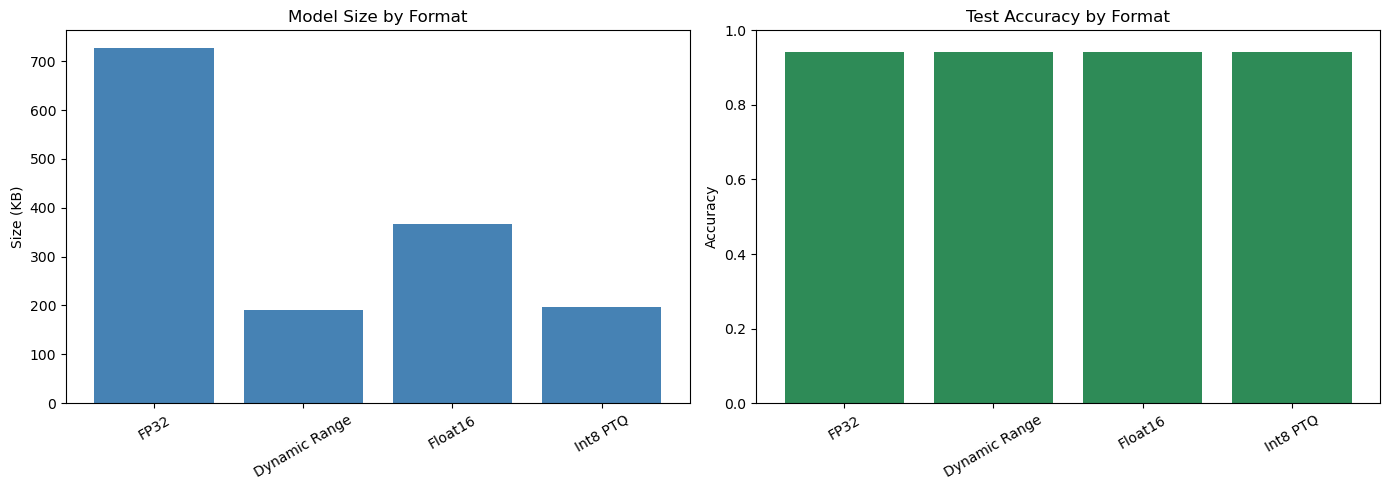

In [95]:
# Create one bar plot for model size and another for test accuracy.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(comparison_df["Format"], comparison_df["Model Size (KB)"], color="steelblue")
axes[0].set_title("Model Size by Format")
axes[0].set_ylabel("Size (KB)")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(comparison_df["Format"], comparison_df["Test Accuracy"], color="seagreen")
axes[1].set_title("Test Accuracy by Format")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


### Confusion Matrix for the PTQ Int8 Model


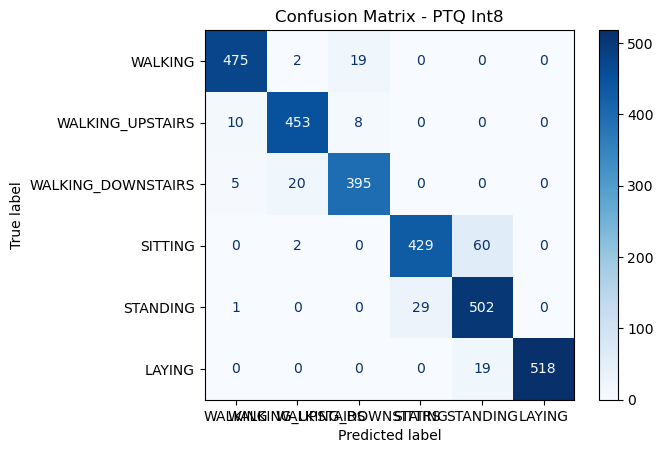

Classification Report - PTQ Int8
                    precision    recall  f1-score   support

           WALKING       0.97      0.96      0.96       496
  WALKING_UPSTAIRS       0.95      0.96      0.96       471
WALKING_DOWNSTAIRS       0.94      0.94      0.94       420
           SITTING       0.94      0.87      0.90       491
          STANDING       0.86      0.94      0.90       532
            LAYING       1.00      0.96      0.98       537

          accuracy                           0.94      2947
         macro avg       0.94      0.94      0.94      2947
      weighted avg       0.94      0.94      0.94      2947



In [96]:
# Plot the confusion matrix for the PTQ int8 model.
# Print the classification report for the PTQ int8 model.

cm_ptq = confusion_matrix(y_test, y_pred_int8_ptq)
disp_ptq = ConfusionMatrixDisplay(confusion_matrix=cm_ptq, display_labels=class_names)
disp_ptq.plot(cmap="Blues")
plt.title("Confusion Matrix - PTQ Int8")
plt.show()

print("Classification Report - PTQ Int8")
print(classification_report(y_test, y_pred_int8_ptq, target_names=class_names))

## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [107]:
print(type(baseline_model))
print(isinstance(baseline_model, tf.keras.Model))

<class 'keras.src.models.sequential.Sequential'>
True


In [106]:
# Create a QAT model from the trained baseline model using TF-MOT.
# Compile it with Adam(1e-4), sparse_categorical_crossentropy, and accuracy.

quantize_model = tfmot.quantization.keras.quantize_model
qat_model = quantize_model(baseline_model)

qat_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

qat_model.summary()


ValueError: `to_quantize` can only either be a keras Sequential or Functional model.

### Fine-Tune the QAT Model


In [76]:
# TODO:
# Fine-tune the QAT model for 8 epochs using validation_split=0.2 and batch_size=64.

qat_history = qat_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=64
)

NameError: name 'qat_model' is not defined

### Evaluate the QAT Keras Model


In [77]:
# TODO:
# Evaluate the QAT Keras model on X_test.
# Print the test accuracy and classification report.

y_prob_qat = qat_model.predict(X_test)
y_pred_qat = np.argmax(y_prob_qat, axis=1)

qat_keras_accuracy = accuracy_score(y_test, y_pred_qat)
print("QAT Keras Test Accuracy:", qat_keras_accuracy)
print(classification_report(y_test, y_pred_qat, target_names=class_names))

NameError: name 'qat_model' is not defined

### Convert the QAT Model to Int8 TensorFlow Lite


In [ ]:
# <-- Enter your code here <--#
# TODO:
# Convert the QAT model to int8 TensorFlow Lite.
# Save the model, compute its size, and evaluate it on the test set.

## 12. PTQ Int8 vs QAT Int8


In [ ]:
# TODO:
# Create a DataFrame comparing PTQ int8 and QAT int8:
# Model, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#


In [ ]:
# TODO:
# Plot the confusion matrix for the QAT int8 model.

# <-- Enter your code here <--#


## 13. Summary Questions

Write short answers to the following:
1. Which quantization method gave the smallest model size?
-- Dynamic range
2. Which quantization method gave the best accuracy among the TensorFlow Lite models?
-- all four are pretty similar.
3. Did QAT improve the final int8 model compared with PTQ int8?

4. Why is this dataset a good fit for a DNN-based TinyML workflow?
5. If you were deploying this model on a resource-constrained device, which version would you choose and why?


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.
